# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

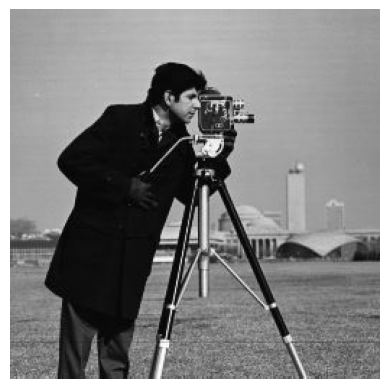

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.jpg").convert("L")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
# scaling factors
cx = 2
cy = 2

print("Original size:", img.size)

Original size: (256, 256)


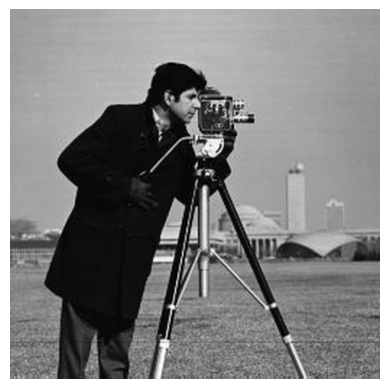

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = int(width * cx)
new_height = int(height * cy)
# Resize the image using PIL's built-in method
scaled_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

plt.imshow(scaled_img, cmap="gray")
plt.axis("off")
plt.show()

In [5]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (256, 256)
Scaled size: (512, 512)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

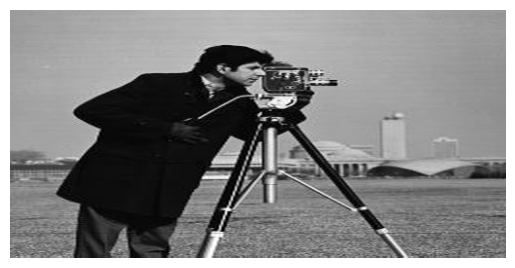

In [6]:
cx = 2
cy = 1

new_width = int(width * cx)
new_height = int(height * cy)

non_uniform_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

plt.imshow(non_uniform_img, cmap="gray")
plt.axis("off")
plt.show()

In [7]:
print("Original size:", img.size)
print("Non-uniform scaled size:", non_uniform_img.size)

Original size: (256, 256)
Non-uniform scaled size: (512, 256)


In [8]:
non_uniform_img.save("task1_non_uniform_scaled.jpg")

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

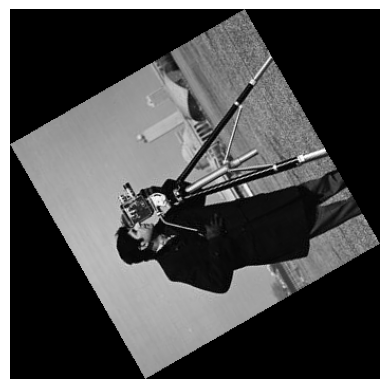

Original size: (256, 256)
Rotated size: (350, 350)


In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC
)

rotated_img.save("task1_2_rotated.jpg")

plt.imshow(rotated_img, cmap="gray")
plt.axis("off")
plt.show()

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

print("Width:", width)
print("Height:", height)

Width: 256
Height: 256


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

new_width = int(width + abs(shear_factor) * height)

shear_matrix = (
    1, -shear_factor, shear_factor * height,
    0, 1, 0
)

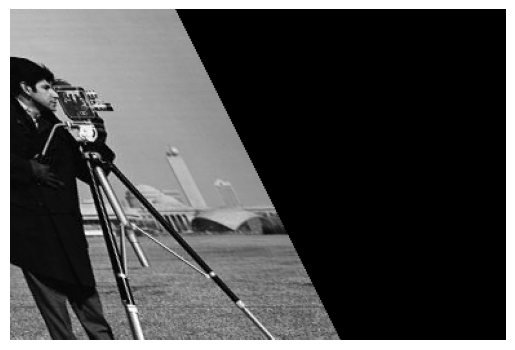

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

plt.imshow(sheared_img, cmap="gray")
plt.axis("off")
plt.show()

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (256, 256)
Sheared size: (384, 256)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

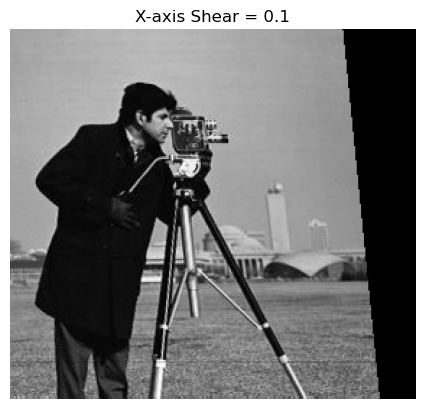

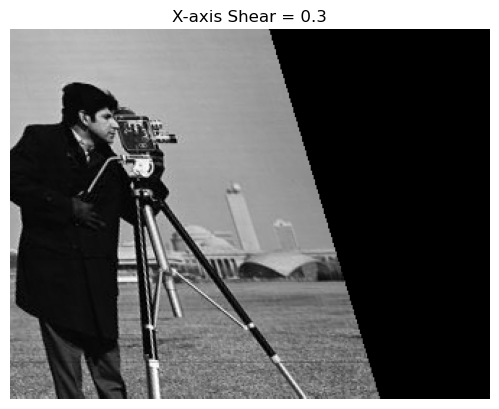

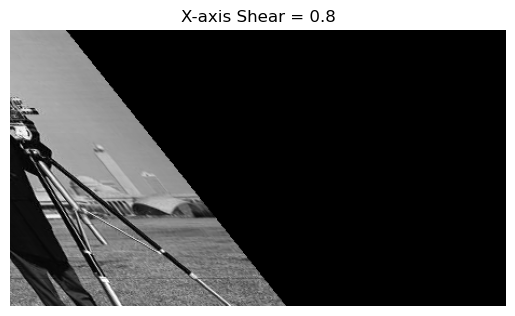

In [14]:
shear_factors = [0.1, 0.3, 0.8]

for shear_factor in shear_factors:
    
    new_width = int(width + abs(shear_factor) * height)

    shear_matrix = (
        1, -shear_factor, shear_factor * height,
        0, 1, 0
    )

    result = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        shear_matrix,
        resample=Image.Resampling.BICUBIC
    )

    plt.figure()
    plt.imshow(result, cmap="gray")
    plt.title(f"X-axis Shear = {shear_factor}")
    plt.axis("off")
    plt.show()

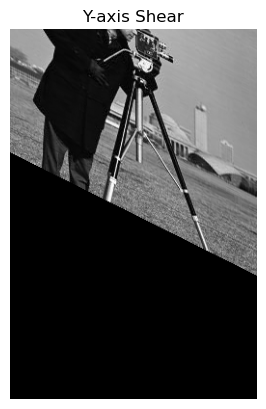

In [15]:
shear_factor = 0.5

new_height = int(height + abs(shear_factor) * width)

y_shear_matrix = (
    1, 0, 0,
    -shear_factor, 1, shear_factor * width
)

y_sheared_img = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    y_shear_matrix,
    resample=Image.Resampling.BICUBIC
)

plt.imshow(y_sheared_img, cmap="gray")
plt.title("Y-axis Shear")
plt.axis("off")
plt.show()

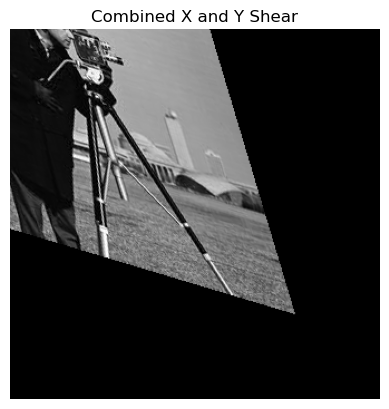

In [16]:
shx = 0.3
shy = 0.3

combined_matrix = (
    1, -shx, shx * height,
    -shy, 1, shy * width
)

combined_img = img.transform(
    (int(width + shx * height),
     int(height + shy * width)),
    Image.Transform.AFFINE,
    combined_matrix,
    resample=Image.Resampling.BICUBIC
)

plt.imshow(combined_img, cmap="gray")
plt.title("Combined X and Y Shear")
plt.axis("off")
plt.show()

### Comparison: As the shear factor increases from 0.1 to 0.8, the image becomes more slanted and the required canvas size increases. X-axis shear changes the horizontal direction, while Y-axis shear changes the vertical direction. Combining X and Y shear produces distortion in both directions.

# Intensity Transformations
Negative · Log · Power Law (Gamma)

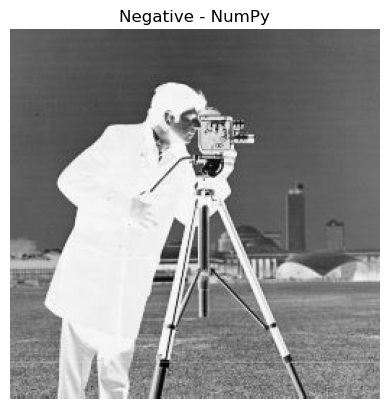

In [17]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_array = np.array(img)

negative_array = 255 - img_array

negative_img = Image.fromarray(negative_array.astype(np.uint8))

plt.imshow(negative_img, cmap="gray")
plt.title("Negative - NumPy")
plt.axis("off")
plt.show()

negative_img.save("negative_numpy.jpg")


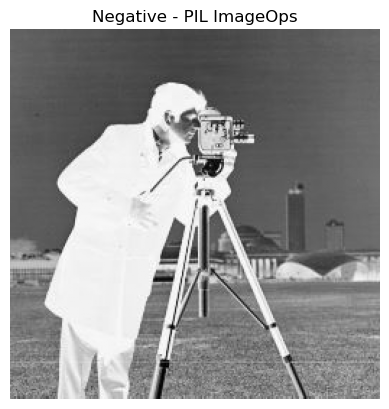

In [19]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(img)

plt.imshow(negative_pil, cmap="gray")
plt.title("Negative - PIL ImageOps")
plt.axis("off")
plt.show()

negative_pil.save("negative_pil.jpg")

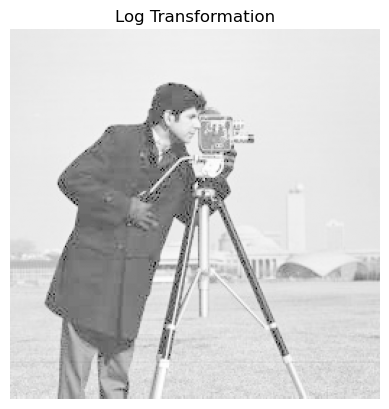

In [20]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# Apply the log transformation to each pixel

img_array = np.array(img).astype(np.float32)

c = 255 / np.log(1 + 255)

log_transformed = c * np.log(1 + img_array)

log_transformed = np.clip(log_transformed, 0, 255)
log_transformed = log_transformed.astype(np.uint8)

log_img = Image.fromarray(log_transformed)

plt.imshow(log_img, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")
plt.show()

log_img.save("log_transformed.jpg")


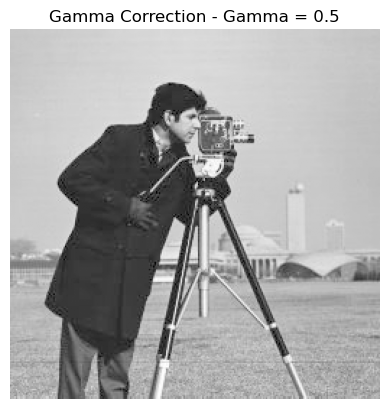

In [21]:
# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

img_array = np.array(img).astype(np.float32) / 255.0

gamma_corrected = 255 * (img_array ** gamma)

gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_corrected)

plt.imshow(gamma_img, cmap="gray")
plt.title("Gamma Correction - Gamma = 0.5")
plt.axis("off")
plt.show()

gamma_img.save("gamma_corrected.jpg")

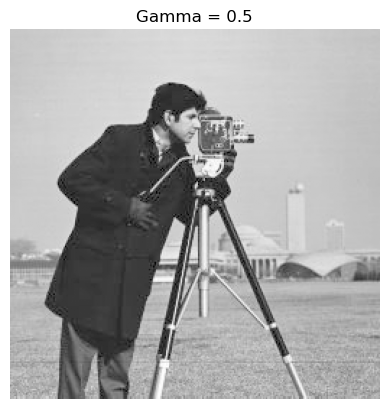

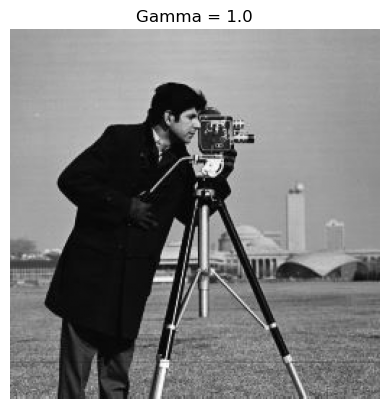

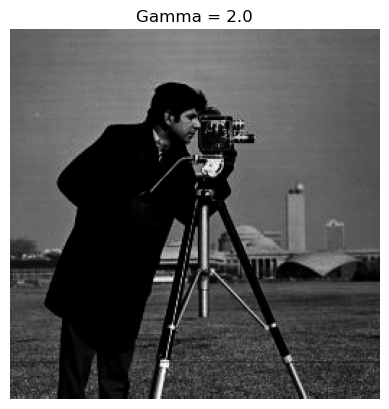

In [22]:
gamma_values = [0.5, 1.0, 2.0]

img_array = np.array(img).astype(np.float32) / 255.0

for gamma in gamma_values:
    
    gamma_corrected = 255 * (img_array ** gamma)
    gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

    plt.figure()
    plt.imshow(gamma_corrected, cmap="gray")
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")
    plt.show()

### Comparison: Gamma values below 1 brighten the image, gamma = 1 keeps the original intensity, and gamma values above 1 darken the image.